In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

In [37]:
# Load dataset (works whether notebook runs from workspace root or notebook folder)
possible_paths = [
    Path("data/women_in_stem.csv"),
    Path("../data/women_in_stem.csv"),
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find women_in_stem.csv in expected locations")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.resolve()}")
print(f"Shape: {df.shape}")
df.head()

Loaded: /Users/rmitta/Desktop/vindhya projects/data/women_in_stem.csv
Shape: (500, 6)


,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74


In [38]:
df.head(10)

,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74
5,India,2001,53.0,54.5,Computer Science,0.54
6,Canada,2002,69.0,23.2,Engineering,0.86
7,India,2000,29.5,38.1,Engineering,0.90
8,USA,2014,57.1,35.7,Biology,0.61
9,China,2020,36.7,64.3,Computer Science,0.96


In [39]:
# Basic structure and data quality checks
print("\nColumns and dtypes:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isna().sum())

print("\nNumeric summary:")
display(df.describe(include=[np.number]))

print("\nUnique categories:")
print("Countries:", sorted(df["Country"].unique()))
print("STEM Fields:", sorted(df["STEM Fields"].unique()))


Columns and dtypes:
Country                        object
Year                            int64
Female Enrollment (%)         float64
Female Graduation Rate (%)    float64
STEM Fields                    object
Gender Gap Index              float64
dtype: object

Missing values by column:
Country                       0
Year                          0
Female Enrollment (%)         0
Female Graduation Rate (%)    0
STEM Fields                   0
Gender Gap Index              0
dtype: int64

Numeric summary:


,Year,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
count,500.00,500.00,500.00,500.00
mean,2011.42,43.94,36.72,0.75
std,7.19,14.32,15.96,0.14
min,2000.00,20.10,10.10,0.50
25%,2005.00,31.58,23.15,0.63
50%,2011.00,43.50,35.90,0.75
75%,2018.00,56.50,50.42,0.86
max,2023.00,69.50,64.90,1.00



Unique categories:
Countries: ['Australia', 'Canada', 'China', 'Germany', 'India', 'USA']
STEM Fields: ['Biology', 'Computer Science', 'Engineering', 'Mathematics']


In [40]:
# Aggregate view for article-ready tables
overall_metrics = df[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]].agg(["mean", "median", "min", "max"]).T
overall_metrics.columns = ["Mean", "Median", "Min", "Max"]
display(overall_metrics)

country_summary = (
    df.groupby("Country")[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
      .mean()
      .sort_values("Female Enrollment (%)", ascending=False)
)

field_summary = (
    df.groupby("STEM Fields")[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
      .mean()
      .sort_values("Female Enrollment (%)", ascending=False)
)

print("Country-level means:")
display(country_summary)

print("Field-level means:")
display(field_summary)

,Mean,Median,Min,Max
Female Enrollment (%),43.94,43.50,20.1,69.5
Female Graduation Rate (%),36.72,35.90,10.1,64.9
Gender Gap Index,0.75,0.75,0.5,1.0


Country-level means:


,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
Country,,,
USA,45.72,36.00,0.72
Canada,44.96,38.07,0.75
Australia,44.04,37.23,0.76
China,43.38,37.43,0.74
India,42.78,35.90,0.74
Germany,42.65,35.40,0.76


Field-level means:


,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
STEM Fields,,,
Mathematics,45.45,35.45,0.76
Engineering,44.01,38.18,0.74
Computer Science,43.08,37.46,0.73
Biology,42.93,35.84,0.76


In [41]:
# Aggregate view for article-ready tables
overall_metrics = df[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]].agg(["mean", "median", "min", "max"]).T
overall_metrics.columns = ["Mean", "Median", "Min", "Max"]
display(overall_metrics)

,Mean,Median,Min,Max
Female Enrollment (%),43.94,43.50,20.1,69.5
Female Graduation Rate (%),36.72,35.90,10.1,64.9
Gender Gap Index,0.75,0.75,0.5,1.0


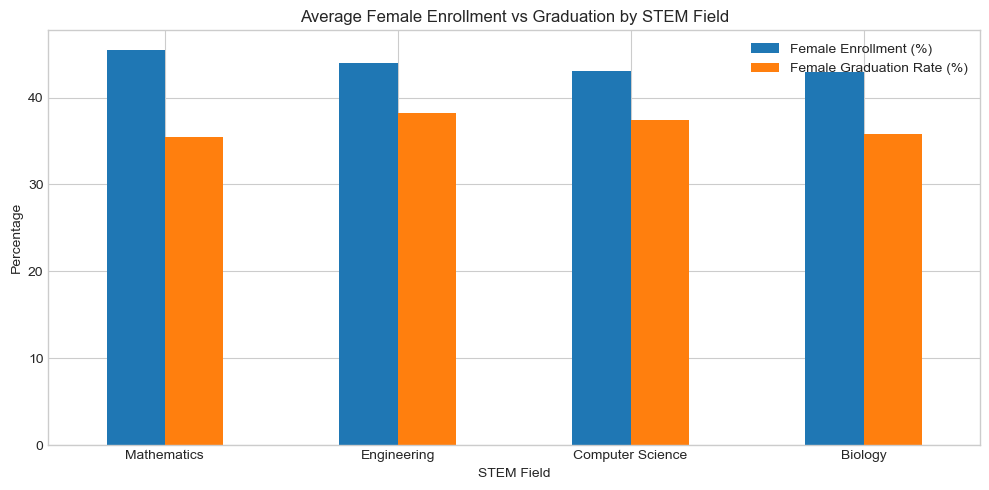

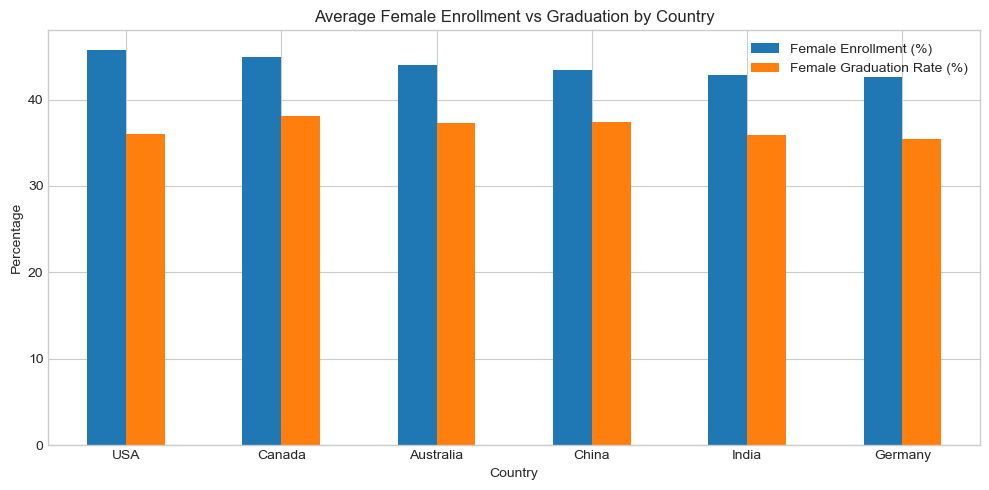

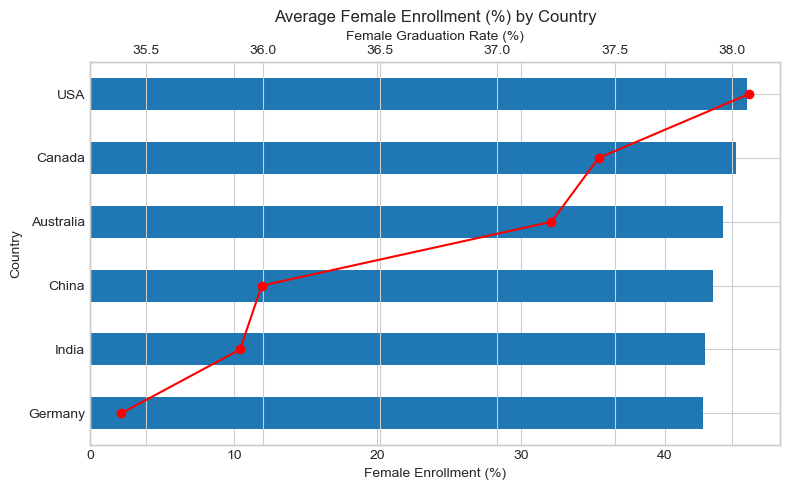

In [42]:
# Visualization 1: Average enrollment and graduation by STEM field
field_plot = field_summary[["Female Enrollment (%)", "Female Graduation Rate (%)"]]
ax = field_plot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Average Female Enrollment vs Graduation by STEM Field")
ax.set_ylabel("Percentage")
ax.set_xlabel("STEM Field")
plt.tight_layout()
plt.show()

# Visualization 2: Average enrollment and graduation by Country
field_plot = country_summary[["Female Enrollment (%)", "Female Graduation Rate (%)"]]
ax = field_plot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Average Female Enrollment vs Graduation by Country")
ax.set_ylabel("Percentage")
ax.set_xlabel("Country")
plt.tight_layout()
plt.show()

# Visualization 3: Average enrollment by country and graduation rate by country
ax = country_summary["Female Enrollment (%)"].sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_title("Average Female Enrollment (%) by Country")
ax.set_xlabel("Female Enrollment (%)")
# plot graduation rate on the same axis
ax2 = ax.twiny()
ax2.plot(country_summary["Female Graduation Rate (%)"].sort_values(), country_summary.index, "ro-", label="Female Graduation Rate (%)")
ax2.set_xlabel("Female Graduation Rate (%)")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
Year,,,
2014,43.29,39.01,0.76
2015,43.59,40.30,0.77
2016,39.37,39.29,0.74
2017,47.47,37.68,0.75
2018,47.27,36.20,0.73
2019,47.51,41.76,0.81
2020,44.89,42.15,0.74
2021,44.89,39.92,0.74
2022,42.64,38.17,0.73


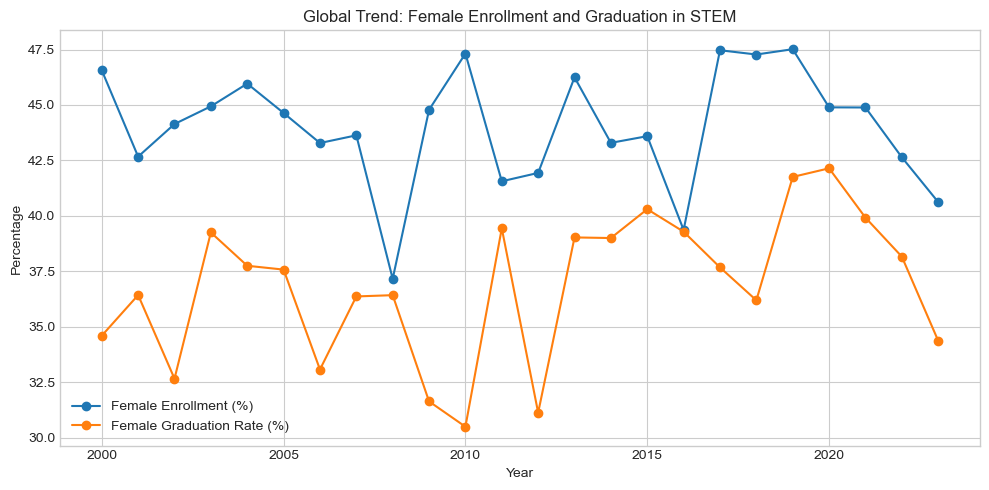

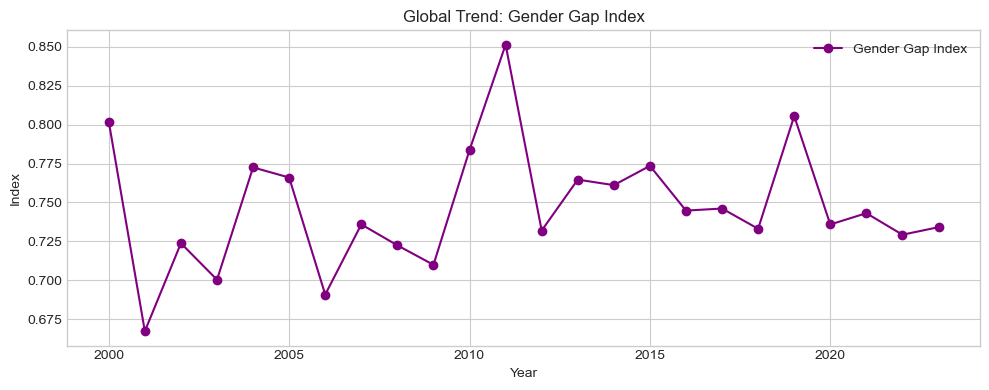

In [43]:
# Trend over time (global averages)
yearly = (
    df.groupby("Year")[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
      .mean()
      .sort_index()
)

display(yearly.tail(10))

ax = yearly[["Female Enrollment (%)", "Female Graduation Rate (%)"]].plot(figsize=(10, 5), marker="o")
ax.set_title("Global Trend: Female Enrollment and Graduation in STEM")
ax.set_ylabel("Percentage")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

ax = yearly[["Gender Gap Index"]].plot(figsize=(10, 4), color="purple", marker="o")
ax.set_title("Global Trend: Gender Gap Index")
ax.set_ylabel("Index")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

Correlation matrix:


,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
Female Enrollment (%),1.00,0.02,-0.08
Female Graduation Rate (%),0.02,1.00,0.03
Gender Gap Index,-0.08,0.03,1.00


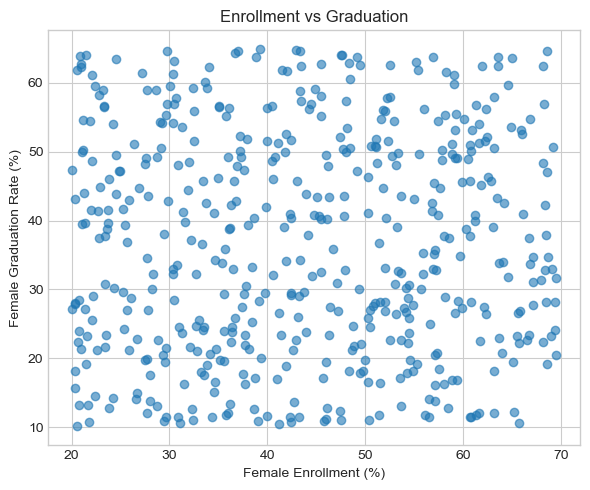

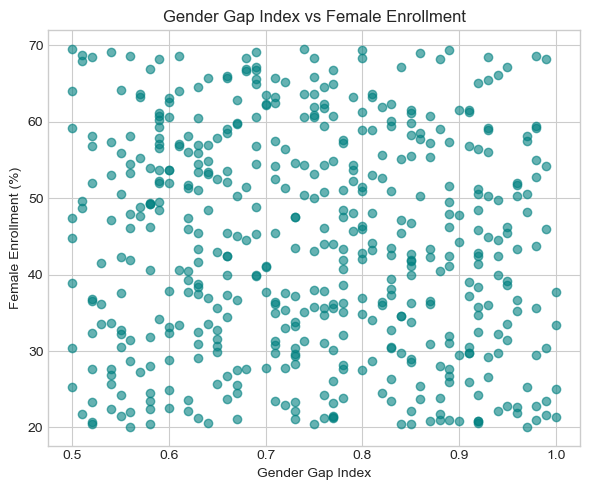

In [44]:
# Relationship analysis: enrollment, graduation, and gender gap
corr = df[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]].corr()
print("Correlation matrix:")
display(corr)

plt.figure(figsize=(6, 5))
plt.scatter(df["Female Enrollment (%)"], df["Female Graduation Rate (%)"], alpha=0.6)
plt.title("Enrollment vs Graduation")
plt.xlabel("Female Enrollment (%)")
plt.ylabel("Female Graduation Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(df["Gender Gap Index"], df["Female Enrollment (%)"], alpha=0.6, color="teal")
plt.title("Gender Gap Index vs Female Enrollment")
plt.xlabel("Gender Gap Index")
plt.ylabel("Female Enrollment (%)")
plt.tight_layout()
plt.show()

In [45]:
#  Time trend significance
from scipy.stats import linregress

print("Has female enrollment in STEM improved over time in this dataset?")

yearly_enrollment = df.groupby("Year")["Female Enrollment (%)"].mean().reset_index()
trend = linregress(yearly_enrollment["Year"], yearly_enrollment["Female Enrollment (%)"])

print(f"- Estimated slope: {trend.slope:.3f} percentage points per year")
print(f"- p-value: {trend.pvalue:.4f}")
print(f"- R²: {trend.rvalue**2:.3f}")

Has female enrollment in STEM improved over time in this dataset?
- Estimated slope: -0.010 percentage points per year
- p-value: 0.8970
- R²: 0.001


In [46]:
# What explains graduation-rate variation more—Country or STEM Field?

def eta_squared_for_group(data, target_col, group_col):
    grand_mean = data[target_col].mean()
    grouped = data.groupby(group_col)[target_col]
    ss_between = sum(len(vals) * (vals.mean() - grand_mean) ** 2 for _, vals in grouped)
    ss_total = ((data[target_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta_country = eta_squared_for_group(df, "Female Graduation Rate (%)", "Country")
eta_field = eta_squared_for_group(df, "Female Graduation Rate (%)", "STEM Fields")
print(f"Eta-squared for Country: {eta_country:.3f}")
print(f"Eta-squared for STEM Field: {eta_field:.3f}")

Eta-squared for Country: 0.004
Eta-squared for STEM Field: 0.005


In [47]:
# Where is the strongest enrollment-to-graduation gap?

df_gap = df.copy()
df_gap["Gap (Enrollment - Graduation)"] = df_gap["Female Enrollment (%)"] - df_gap["Female Graduation Rate (%)"]

combo_gap = (
    df_gap.groupby(["Country", "STEM Fields"])["Gap (Enrollment - Graduation)"]
    .mean()
    .sort_values(ascending=False)
)

top5 = combo_gap.head(5).round(2)
print("Top 5 country-field combinations with largest enrollment-to-graduation gap:")
display(top5)

Top 5 country-field combinations with largest enrollment-to-graduation gap:


Country    STEM Fields
China      Mathematics    16.10
USA        Mathematics    13.35
Germany    Biology        11.81
Australia  Engineering    11.33
USA        Biology        10.85
Name: Gap (Enrollment - Graduation), dtype: float64

In [48]:
# Are there distinct participation profiles in the data?
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

panel = (
    df.groupby(["Country", "Year"])[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
      .mean()
      .reset_index()
)

X = panel[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
panel["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = panel.groupby("Cluster")[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]].mean().round(2)
cluster_sizes = panel["Cluster"].value_counts().sort_index()
country_cluster_mix = (pd.crosstab(panel["Country"], panel["Cluster"], normalize="index") * 100).round(1)
print("\nCluster profiles:")
display(cluster_profile)
print("\nCluster sizes:")
display(cluster_sizes)
print("\nCountry-cluster mix (% of each country's observations in each cluster):")
display(country_cluster_mix)


Cluster profiles:


,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
Cluster,,,
0,48.76,40.74,0.65
1,42.13,26.46,0.77
2,42.17,42.04,0.80



Cluster sizes:


Cluster
0    41
1    48
2    53
Name: count, dtype: int64


Country-cluster mix (% of each country's observations in each cluster):


Cluster,0,1,2
Country,,,
Australia,29.2,29.2,41.7
Canada,33.3,29.2,37.5
China,25.0,41.7,33.3
Germany,12.5,37.5,50.0
India,22.7,36.4,40.9
USA,50.0,29.2,20.8


In [49]:
# Which countries are improving fastest across multiple indicators?

country_year = (
    df.groupby(["Country", "Year"])[["Female Enrollment (%)", "Female Graduation Rate (%)", "Gender Gap Index"]]
      .mean()
      .reset_index()
)

rows = []
for country, part in country_year.groupby("Country"):
    if part["Year"].nunique() < 2:
        continue
    s_enroll = linregress(part["Year"], part["Female Enrollment (%)"]).slope
    s_grad = linregress(part["Year"], part["Female Graduation Rate (%)"]).slope
    s_gap_index = linregress(part["Year"], part["Gender Gap Index"]).slope
    rows.append({
        "Country": country,
        "Enrollment Slope": s_enroll,
        "Graduation Slope": s_grad,
        "GenderGapIndex Slope": s_gap_index,
    })

progress = pd.DataFrame(rows)
for col in ["Enrollment Slope", "Graduation Slope", "GenderGapIndex Slope"]:
    progress[f"z_{col}"] = (progress[col] - progress[col].mean()) / progress[col].std(ddof=0)

progress["Progress Score"] = progress[["z_Enrollment Slope", "z_Graduation Slope", "z_GenderGapIndex Slope"]].mean(axis=1)
progress = progress.sort_values("Progress Score", ascending=False).round(4)
progress

,Country,Enrollment Slope,Graduation Slope,GenderGapIndex Slope,z_Enrollment Slope,z_Graduation Slope,z_GenderGapIndex Slope,Progress Score
4,India,0.01,0.35,4.20e-03,0.29,0.98,1.15,0.81
2,China,0.21,0.17,2.30e-03,1.80,-0.54,0.57,0.61
1,Canada,0.04,0.43,-4.40e-03,0.50,1.65,-1.53,0.21
5,USA,-0.09,0.21,3.70e-03,-0.50,-0.19,0.99,0.10
3,Germany,-0.17,0.09,-0.00e+00,-1.14,-1.25,-0.18,-0.85
0,Australia,-0.14,0.16,-2.60e-03,-0.94,-0.65,-1.00,-0.86


In [50]:
#  Where are the strongest worsening retention risks?

risk_df = df.copy()
risk_df["Gap (Enrollment - Graduation)"] = risk_df["Female Enrollment (%)"] - risk_df["Female Graduation Rate (%)"]

slopes = []
for (country, field), part in risk_df.groupby(["Country", "STEM Fields"]):
    if part["Year"].nunique() < 4:
        continue
    slope = linregress(part["Year"], part["Gap (Enrollment - Graduation)"]).slope
    slopes.append({
        "Country": country,
        "STEM Field": field,
        "Gap Trend Slope": slope,
        "Avg Gap": part["Gap (Enrollment - Graduation)"].mean(),
        "Rows": len(part),
    })

risk_trend = pd.DataFrame(slopes)
worst = risk_trend.sort_values(["Gap Trend Slope", "Avg Gap"], ascending=False).head(8).round(3)
worst

,Country,STEM Field,Gap Trend Slope,Avg Gap,Rows
21,USA,Computer Science,0.74,10.63,15
3,Australia,Mathematics,0.68,6.25,34
13,Germany,Computer Science,0.50,4.76,19
10,China,Engineering,0.44,2.65,30
9,China,Computer Science,0.28,4.78,14
0,Australia,Biology,0.03,6.76,18
14,Germany,Engineering,0.02,3.11,18
4,Canada,Biology,-0.01,1.61,16
